In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import f90nml
import cftime
import numpy as np
import xarray_tools as xrt
from notebook_metadata import create_savefig
from pathlib import Path

savefig = create_savefig(dir='/scratch/tm70/mrd599/plots', nb='esm_historical_ghg_check.ipynb')

In [2]:
# Conversion factors for ESM1.6 https://github.com/ACCESS-NRI/CMIP7-Input/issues/47
air_molar_mass = 28.97
MOLAR_MASS_LOOKUP = {
    "co2": 44.01,
    "n2o": 44.01,
    "ch4": 16.04,
    "cfc11": 137.37,
    "cfc12": 120.91,
    "cfc113": 187.37,
    "hcfc22": 86.47,
    "hfc125": 120.02,
    "hfc134a": 102.03}

In [3]:
# All gases
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
gas_mmr = {}
scale = {'ppm':1e-6, 'ppb':1e-9, 'ppt':1e-12}
base = Path('/g/data/qv56/replicas/input4MIPs/CMIP7/CMIP/CR/CR-CMIP-1-0-0/atmos/yr')
for g in MOLAR_MASS_LOOKUP:
    f = base / f'{g}/gm/v20250228/{g}_input4MIPs_GHGConcentrations_CMIP_CR-CMIP-1-0-0_gm_1750-2022.nc'
    d = xr.open_dataset(f, decode_times=time_coder)
    gas_mmr[g] = d[g] * MOLAR_MASS_LOOKUP[g] / air_molar_mass * scale[d[g].units]

In [5]:
# ESM1.6 cscenario_mod.F90
#   Integer, Parameter :: S_CO2     = 1               ! Carbon dioxide (CO2)
#   Integer, Parameter :: S_CH4     = 2               ! methane (CH4)
#   Integer, Parameter :: S_N2O     = 3               ! nitrous oxide (N2O)
#   Integer, Parameter :: S_CFC11   = 4               ! Trichlorofluoromethane (CCl3F, "CFC-11")
#   Integer, Parameter :: S_CFC12   = 5               ! dichlorodifluoromethane (CCl2F2, "CFC-12")
#   Integer, Parameter :: S_SO4     = 6               ! HadCM2-style anthropogenic sulphate loading pattern
#   Integer, Parameter :: S_CFC113  = 8               !
#   Integer, Parameter :: S_HCFC22  = 9               !
#   Integer, Parameter :: S_HFC125  = 10              !
#   Integer, Parameter :: S_HFC134A = 11              !
S_CO2     = 1
S_CH4     = 2
S_N2O     = 3
S_CFC11   = 4
S_CFC12   = 5
S_CFC113  = 8
S_HCFC22  = 9
S_HFC125  = 10
S_HFC134A = 11
gas_lookup = {
    'co2': S_CO2,
    'ch4': S_CH4,
    'n2o': S_N2O,
    'cfc11': S_CFC11,
    'cfc12': S_CFC12,
    'cfc113': S_CFC113,
    'hcfc22': S_HCFC22,
    'hfc125': S_HFC125,
    'hfc134a': S_HFC134A
}
for g, i in gas_lookup.items():
    gas_lookup[g] = i-1

In [6]:
nml = f90nml.read('/scratch/tm70/mrd599/access-esm1.6-experiments/dev-historical+concentrations/atmosphere/namelists')
gas_model_cmip6 = {}
years = nml['clmchfcg']['clim_fcg_years'][0]
# Create dataarrays with Jan 1 date
times = np.array([cftime.DatetimeProlepticGregorian(y, 1,  1, 0, 0, 0) for y in years])
for g, i in gas_lookup.items():
    gas_model_cmip6[g] = xr.DataArray(np.array(nml['clmchfcg']['clim_fcg_levls'][i]), dims=['time'])
    gas_model_cmip6[g].coords['time'] = times

In [7]:
nml = f90nml.read('cylc-run/u-dq819/run1/share/HI_access-esm1.6-configs/atmosphere/namelists')
gas_model = {}
years = nml['clmchfcg']['clim_fcg_years'][0]
# Create dataarrays with Jan 1 date
times = np.array([cftime.DatetimeProlepticGregorian(y, 1,  1, 0, 0, 0) for y in years])
for g, i in gas_lookup.items():
    gas_model[g] = xr.DataArray(np.array(nml['clmchfcg']['clim_fcg_levls'][i]), dims=['time'])
    gas_model[g].coords['time'] = times

# These should be zero
assert max(nml['clmchfcg']['clim_fcg_levls'][5]) == 0.
assert max(nml['clmchfcg']['clim_fcg_levls'][6]) == 0.

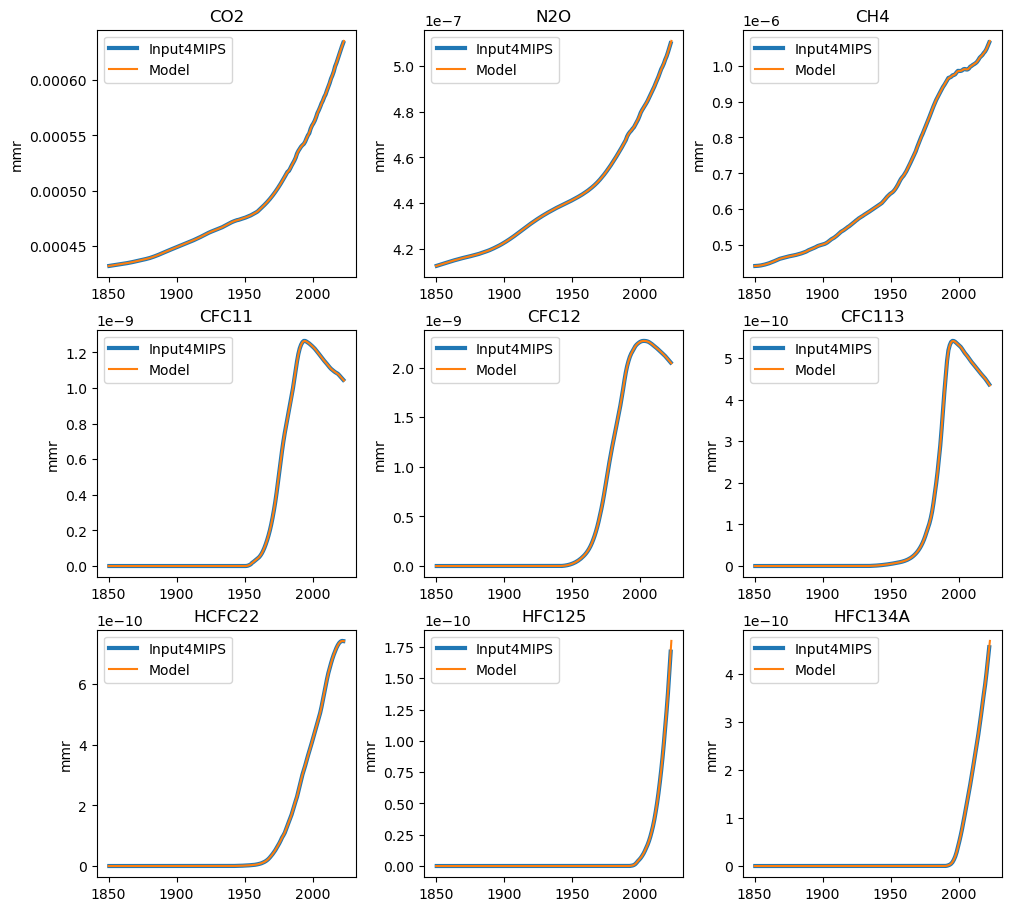

In [8]:
fig, axes = plt.subplots(3,3, layout='constrained', figsize=(10,9))
axes = axes.flatten()
for i, g in enumerate(gas_mmr):
    ax = axes[i]
    # gas_model_cmip6[g].plot(ax=ax, label='CMIP6')
    gas_mmr[g][100:].plot(ax=ax, label='Input4MIPS', lw=3)
    gas_model[g].plot(ax=ax, label='Model')
    # gas_model[g].plot.scatter(ax=ax, label='Model', color='C1', s=5)
    ax.legend()
    ax.set_title(g.upper())
    ax.set_ylabel('mmr')
    ax.set_xlabel('')
savefig('ghg.png')

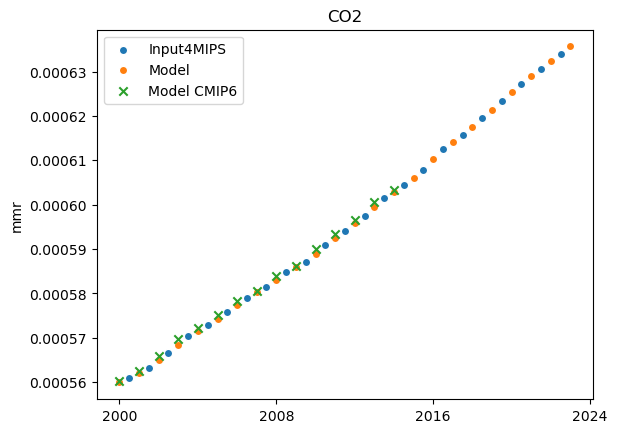

In [9]:
fig, axes = plt.subplots()
g = 'co2'
gas_mmr[g][250:].plot.scatter(label='Input4MIPS')
gas_model[g][150:].plot.scatter(label='Model')
gas_model_cmip6[g][150:].plot.scatter(label='Model CMIP6', marker='x')
axes.legend()
axes.set_title('CO2')
axes.set_ylabel('mmr')
axes.set_xlabel('')
savefig('co2.png')
